<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGe_017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Grid and attractors
N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
x1, x2 = np.pi/4, 7*np.pi/4
theta = np.pi / 3

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

A1 = gaussian(x1, sigma, A)
A2 = gaussian(x2, sigma, A) * np.cos(theta)
phi = A1 + A2
history = [phi.copy()]


In [2]:
dt = 0.01
gamma = 0.005
lam = 0.1
T = 0.02  # thermal noise amplitude

def laplacian(phi):
    lap = np.roll(phi, 1) - 2*phi + np.roll(phi, -1)
    return np.nan_to_num(lap)

def evolve(phi):
    lap = laplacian(phi)
    nonlinear = lam * np.clip(phi, -1.0, 1.0)**3
    noise = T * np.random.normal(0, 1, size=len(phi))
    phi = phi + dt * (lap - gamma * phi + nonlinear + noise)
    return np.clip(phi, -1.0, 1.0)

for t in range(300):
    phi = evolve(phi)
    if t % 50 == 0:
        history.append(phi.copy())


In [3]:
def correlation(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return (np.dot(a, b) / denom) if denom > 0 else 0.0

def collapse_index(phi, eps=1e-3):
    return np.sum(np.abs(phi) < eps) / len(phi)

corr_A1 = [correlation(h, A1) for h in history]
corr_A2 = [correlation(h, A2) for h in history]
collapse = [collapse_index(h) for h in history]


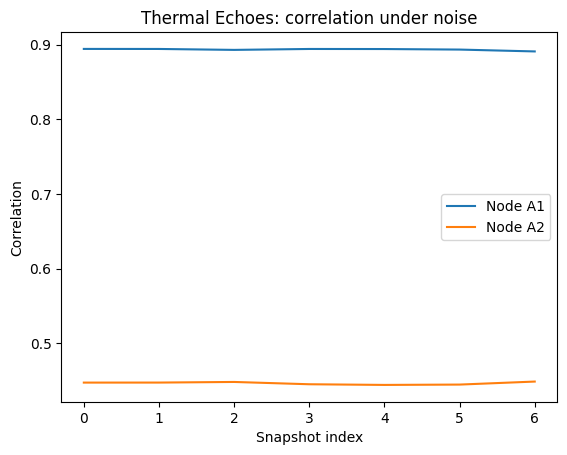

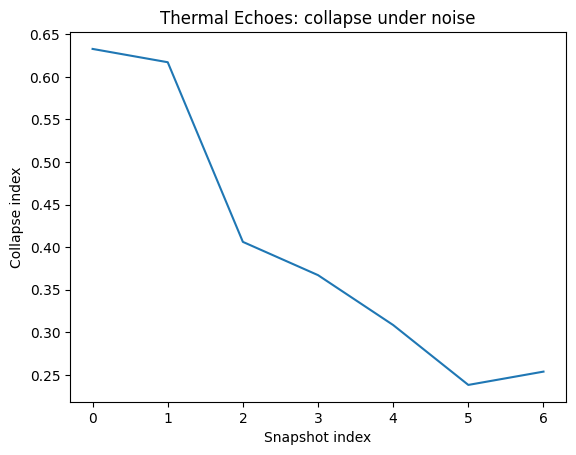

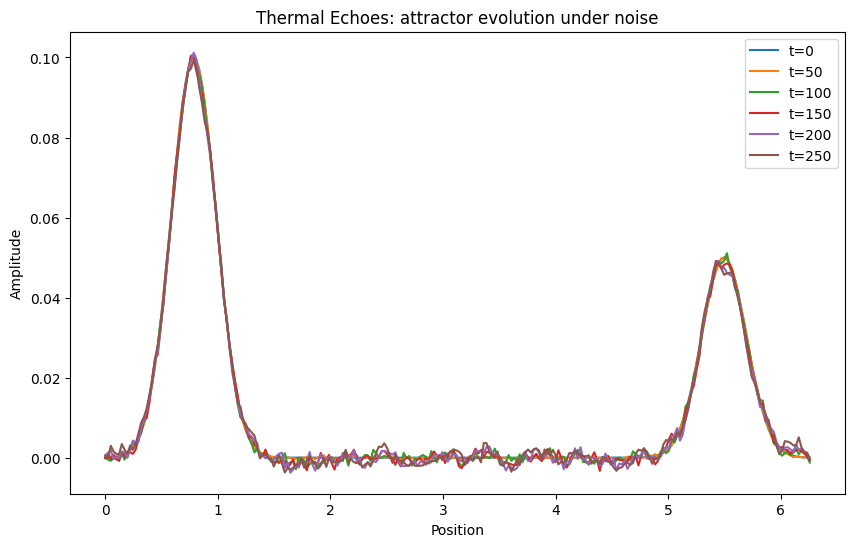

In [4]:
# Correlation plot
plt.plot(corr_A1, label="Node A1")
plt.plot(corr_A2, label="Node A2")
plt.xlabel("Snapshot index")
plt.ylabel("Correlation")
plt.title("Thermal Echoes: correlation under noise")
plt.legend()
plt.show()

# Collapse index
plt.plot(collapse)
plt.xlabel("Snapshot index")
plt.ylabel("Collapse index")
plt.title("Thermal Echoes: collapse under noise")
plt.show()

# Amplitude evolution
plt.figure(figsize=(10,6))
for i, h in enumerate(history[:6]):
    plt.plot(x, h, label=f"t={i*50}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Thermal Echoes: attractor evolution under noise")
plt.legend()
plt.show()
